# Анализ данных


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


## Загрузка файла

In [ ]:
# Загрузка данных
file_path = "drive/MyDrive/games2024.xlsx"
df = pd.read_excel(file_path)

# Первые строки
df.dropna(subset=['КоличествоДействий'], inplace=True)
df.head()

,Турнир,ИгрокФИО,Амплуа,Команда,Матч,Данные,КоличествоДействий
0,Молодежное первенство,Алферов Иван Владимирович,AM,Урал-М,Урал-М 2 : 3 Динамо-М (08.03.2024),Борьба за нейтральный мяч неудачная,4
1,Молодежное первенство,Алферов Иван Владимирович,AM,Урал-М,Урал-М 2 : 3 Динамо-М (08.03.2024),Передача прогрессивная точная,12
2,Молодежное первенство,Алферов Иван Владимирович,AM,Урал-М,Урал-М 2 : 3 Динамо-М (08.03.2024),Потеря мяча,4
3,Молодежное первенство,Алферов Иван Владимирович,AM,Урал-М,Урал-М 2 : 3 Динамо-М (08.03.2024),Фол,3
4,Молодежное первенство,Алферов Иван Владимирович,AM,Урал-М,Урал-М 2 : 3 Динамо-М (08.03.2024),Блокировка передачи,1


## Общая информация

In [ ]:
print("Размер данных:", df.shape)
df.info()

print("\nПропущенные значения:")
print(df.isnull().sum())

Размер данных: (853907, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 853907 entries, 0 to 853909
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Турнир              853907 non-null  object
 1   ИгрокФИО            853907 non-null  object
 2   Амплуа              853907 non-null  object
 3   Команда             853907 non-null  object
 4   Матч                853907 non-null  object
 5   Данные              853907 non-null  object
 6   КоличествоДействий  853907 non-null  object
dtypes: object(7)
memory usage: 52.1+ MB

Пропущенные значения:
Турнир                0
ИгрокФИО              0
Амплуа                0
Команда               0
Матч                  0
Данные                0
КоличествоДействий    0
dtype: int64


##  Обзор уникальных значений и сущностей

In [ ]:
summary = {
    "Число записей": len(df),
    "Уникальных игроков": df["ИгрокФИО"].nunique(),
    "Уникальных матчей": df["Матч"].nunique(),
    "Уникальных команд": df["Команда"].nunique(),
    "Уникальных типов действий": df["Данные"].nunique(),
    "Позиции на поле (амплуа)": df["Амплуа"].unique().tolist(),
    "Уникальных турниров": df["Турнир"].nunique()
}
summary

{'Число записей': 853907,
 'Уникальных игроков': 2016,
 'Уникальных матчей': 1196,
 'Уникальных команд': 77,
 'Уникальных типов действий': 110,
 'Позиции на поле (амплуа)': ['AM',
  'W',
  'FB',
  'GK',
  'DM',
  'CD',
  'ST',
  'Амплуа'],
 'Уникальных турниров': 5}

##  Топ-10 игроков по активности (по количеству действий)

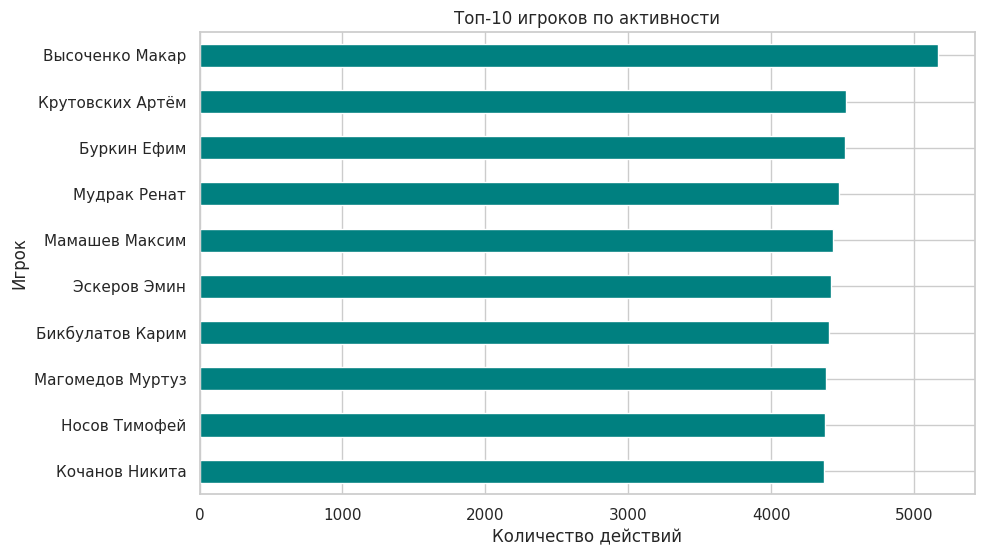

In [ ]:
df["КоличествоДействий"] = pd.to_numeric(df["КоличествоДействий"], errors="coerce")

top_players = df.groupby("ИгрокФИО")["КоличествоДействий"].sum().sort_values(ascending=False).head(10)
top_players.plot(kind="barh", figsize=(10, 6), color="teal")
plt.gca().invert_yaxis()
plt.title("Топ-10 игроков по активности")
plt.xlabel("Количество действий")
plt.ylabel("Игрок")
plt.show()


## Частотность игровых действий (топ-15)

<ipython-input-7-6f234c87bd3c>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_actions.index, x=top_actions.values, palette="viridis")


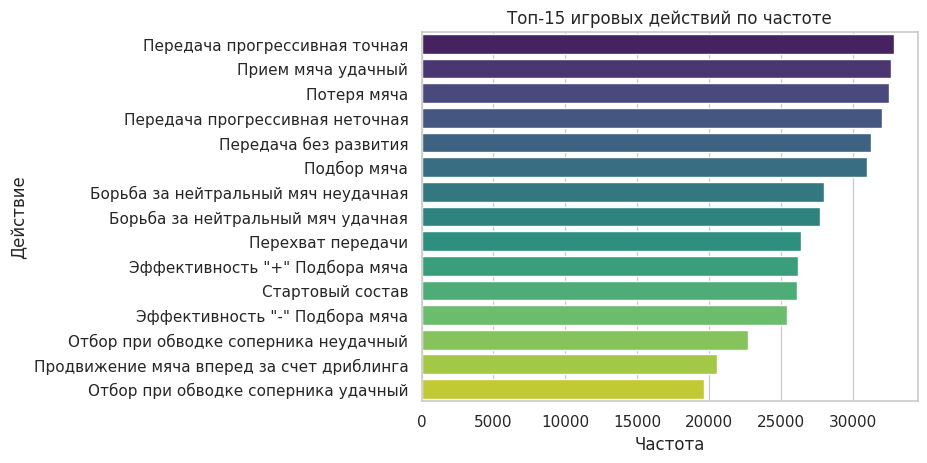

In [ ]:
top_actions = df["Данные"].value_counts().head(15)
sns.barplot(y=top_actions.index, x=top_actions.values, palette="viridis")
plt.title("Топ-15 игровых действий по частоте")
plt.xlabel("Частота")
plt.ylabel("Действие")
plt.show()


## Сравнение действий по амплуа (позициям)

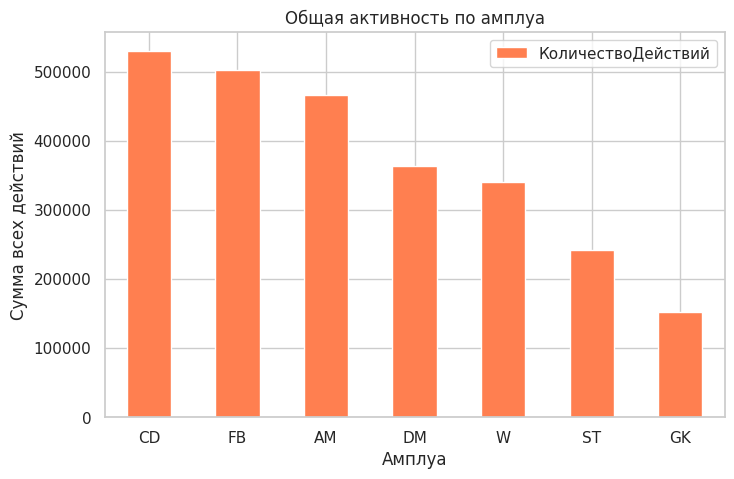

In [ ]:
df = df[df["Амплуа"] != "Амплуа"]

pivot_amplua = df.pivot_table(index="Амплуа", values="КоличествоДействий", aggfunc="sum").sort_values("КоличествоДействий", ascending=False)
pivot_amplua.plot(kind="bar", figsize=(8, 5), color="coral")
plt.title("Общая активность по амплуа")
plt.ylabel("Сумма всех действий")
plt.xlabel("Амплуа")
plt.xticks(rotation=0)
plt.show()

## Тепловая карта: 10 популярных действий против амплуа

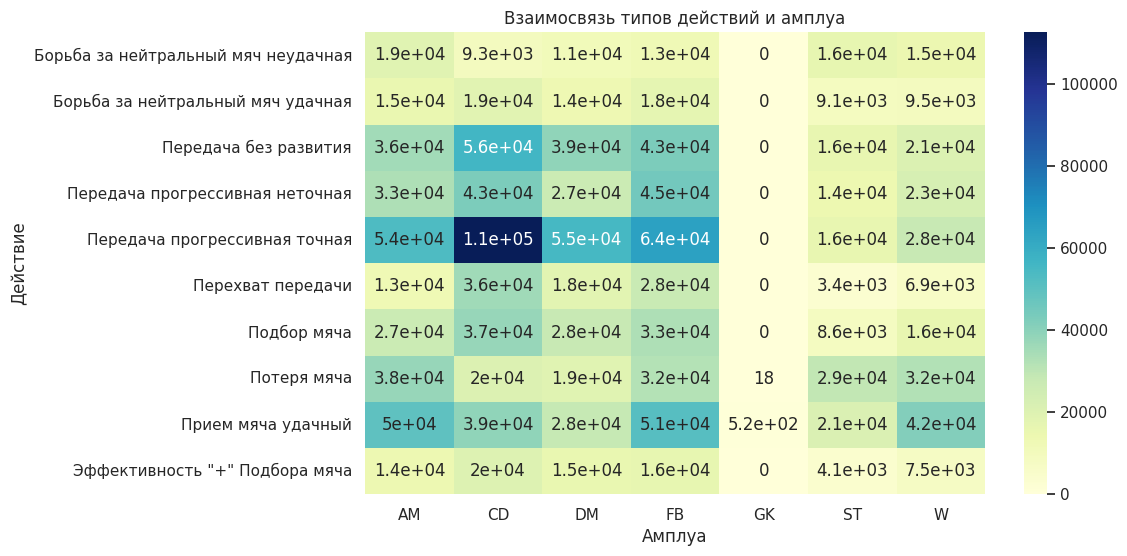

In [ ]:
top10_actions = df["Данные"].value_counts().head(10).index
heatmap_data = df[df["Данные"].isin(top10_actions)].pivot_table(
    index="Данные", columns="Амплуа", values="КоличествоДействий", aggfunc="sum", fill_value=0
)
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu")
plt.title("Взаимосвязь типов действий и амплуа")
plt.xlabel("Амплуа")
plt.ylabel("Действие")
plt.show()


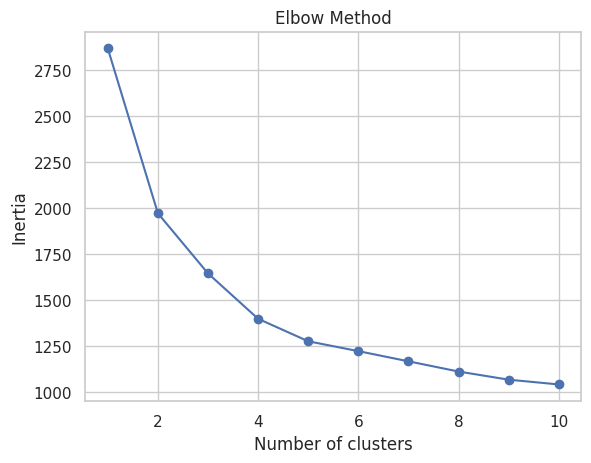

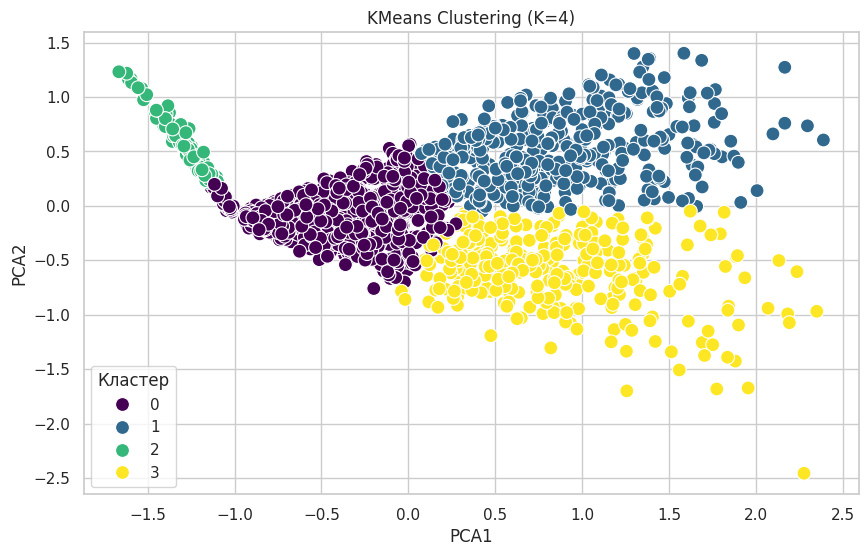

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Создание матрицы игрок-действие
matrix = df.pivot_table(index='ИгрокФИО', columns='Данные', values='КоличествоДействий', aggfunc='sum', fill_value=0)
filtered = matrix[matrix.sum(axis=1) > 100]  # Фильтрация
scaled = MinMaxScaler().fit_transform(filtered)

# Метод локтя для выбора числа кластеров
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Оптимальное число кластеров
best_k = 4

# Кластеризация KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(scaled)

# Визуализация через PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled)
cluster_df = pd.DataFrame(reduced, columns=["PCA1", "PCA2"])
cluster_df["ИгрокФИО"] = filtered.index
cluster_df["Кластер"] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_df, x="PCA1", y="PCA2", hue="Кластер", palette="viridis", s=100)
plt.title(f"KMeans Clustering (K={best_k})")
plt.show()

## Радарные графики для 3 топ-игроков

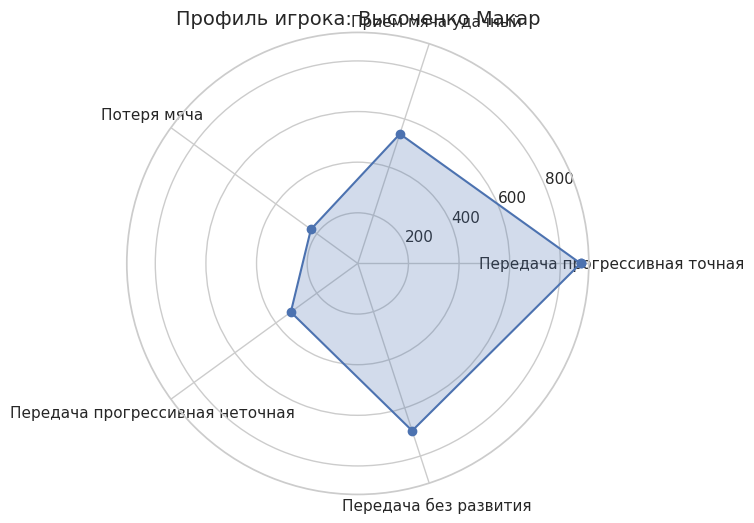

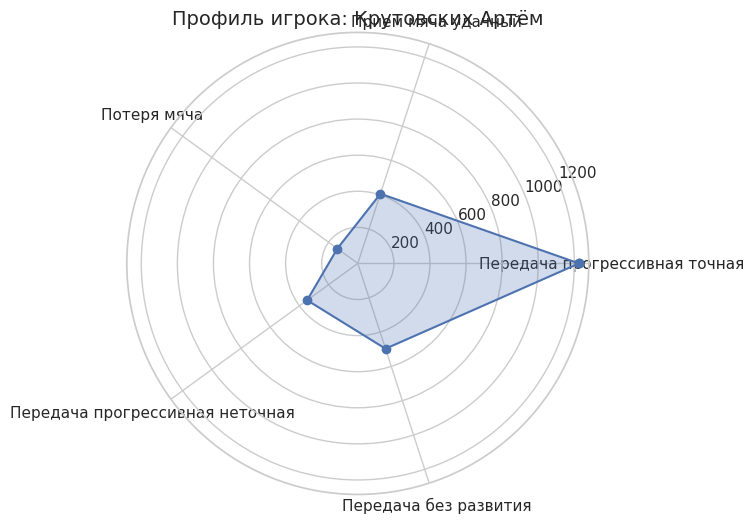

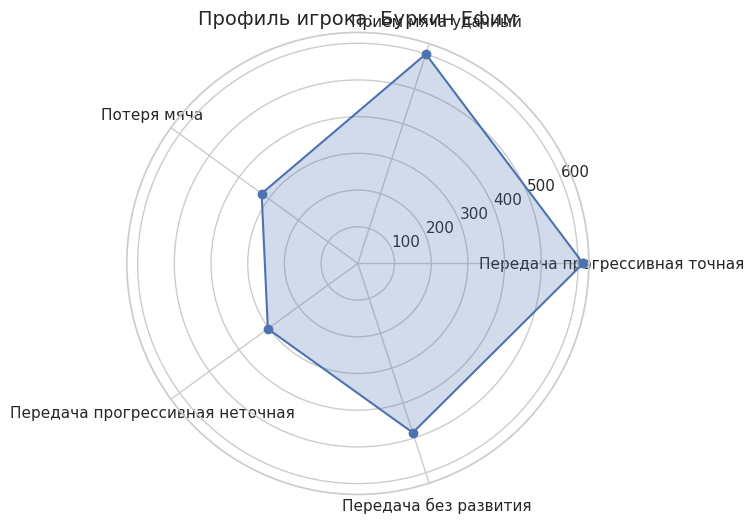

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Выбор 3 топ-игроков
top3 = df.groupby("ИгрокФИО")["КоличествоДействий"].sum().sort_values(ascending=False).head(3).index.tolist()
actions = df["Данные"].value_counts().head(5).index.tolist()  # 5 наиболее часто встречающихся действий

for player in top3:
    player_data = df[df["ИгрокФИО"] == player]
    values = [player_data[player_data["Данные"] == a]["КоличествоДействий"].sum() for a in actions]

    # Радарный график
    angles = np.linspace(0, 2 * np.pi, len(actions), endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, marker='o')
    ax.fill(angles, values, alpha=0.25)
    ax.set_title(f"Профиль игрока: {player}", size=14)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(actions)
    plt.show()


## Сравнение активности команд

<ipython-input-12-aa2eb7179293>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_activity.values, y=team_activity.index, palette="coolwarm")


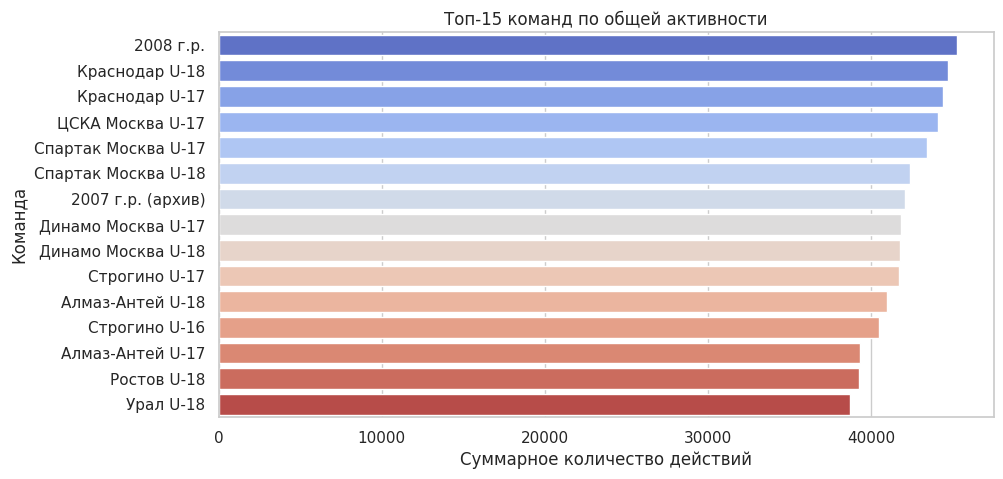

In [ ]:
team_activity = df.groupby("Команда")["КоличествоДействий"].sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,5))
sns.barplot(x=team_activity.values, y=team_activity.index, palette="coolwarm")
plt.title("Топ-15 команд по общей активности")
plt.xlabel("Суммарное количество действий")
plt.show()


## Активность по турнирам

<ipython-input-13-8c22495359db>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tournament_activity.values, y=tournament_activity.index, palette="magma")


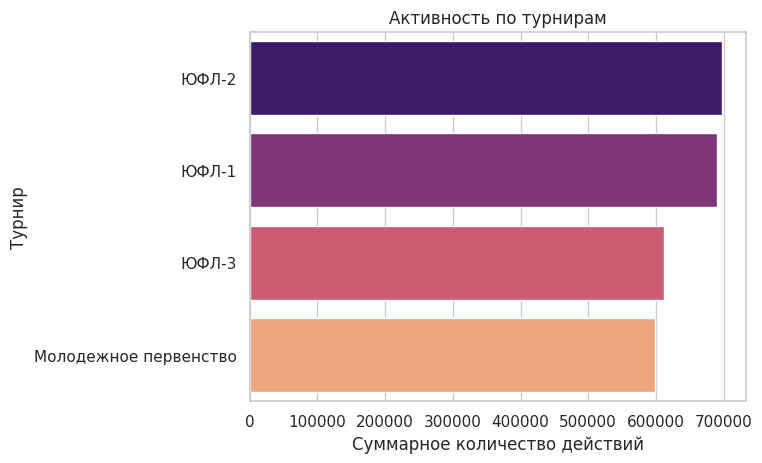

In [ ]:
tournament_activity = df.groupby("Турнир")["КоличествоДействий"].sum().sort_values(ascending=False)
sns.barplot(x=tournament_activity.values, y=tournament_activity.index, palette="magma")
plt.title("Активность по турнирам")
plt.xlabel("Суммарное количество действий")
plt.show()


# Понижение размерности

## Создание матрицы игрок-действие


In [ ]:
st_players = df.copy()

matrix_st = st_players.pivot_table(
    index='ИгрокФИО',
    columns='Данные',
    values='КоличествоДействий',
    aggfunc='sum',
    fill_value=0
)

print(f"Размерность матрицы: {matrix_st.shape}")

Размерность матрицы: (2015, 109)


## Понижение размерности с помощью PCA

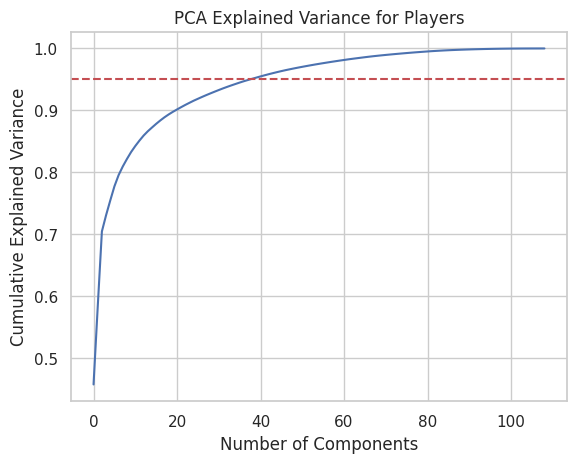

Уменьшено с 109 до 39 компонент


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Нормализация данных данных
scaler = MinMaxScaler()
scaled_st = scaler.fit_transform(matrix_st)

# Анализ объясненной дисперсии
pca_full = PCA().fit(scaled_st)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title('PCA Explained Variance for Players')
plt.show()

# Выбор числа компонент для 95% дисперсии
pca = PCA(n_components=0.95)
reduced_st = pca.fit_transform(scaled_st)
print(f"Уменьшено с {scaled_st.shape[1]} до {pca.n_components_} компонент")

## Применяем t-SNE для визуализации первых двух компонент

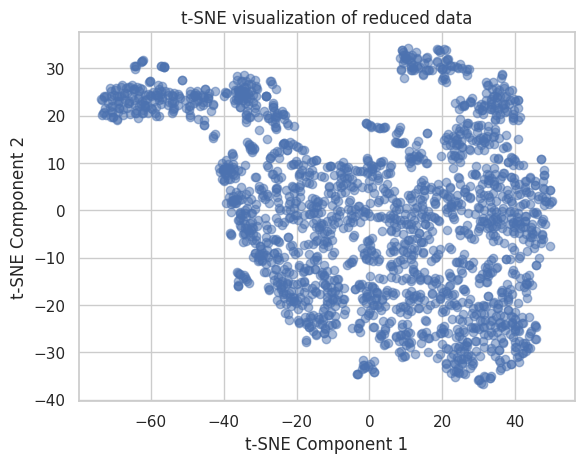

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(reduced_st)

# Визуализация
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], alpha=0.5)
plt.title("t-SNE visualization of reduced data")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

## Корреляция между расстояниями

In [ ]:
from scipy.spatial.distance import pdist, squareform

# Расстояния в исходном пространстве
original_distances = squareform(pdist(scaled_st))

# Расстояния в пространстве после PCA
reduced_distances = squareform(pdist(reduced_st))

correlation = np.corrcoef(original_distances.flatten(), reduced_distances.flatten())[0, 1]
print(f"Корреляция между расстояниями: {correlation}")

Корреляция между расстояниями: 0.9988704362568959


## Создаем DataFrame с новыми компонентами

In [ ]:
reduced_df = pd.DataFrame(reduced_st, index=matrix_st.index, columns=[f"PC{i+1}" for i in range(pca.n_components_)])
print(reduced_df.head())

                               PC1       PC2       PC3       PC4       PC5  \
ИгрокФИО                                                                     
05 НоНейм                -0.889849 -0.199110  0.152138 -0.045572 -0.118135   
Абдинов Фарид             0.208053  0.255637  0.533105 -0.016844  0.049337   
Абдулкадыров Джамалутдин  0.874478  0.295346  0.459048  0.467902 -0.208638   
Абдулкин Николай         -0.449273 -0.204796  0.120841 -0.030308  0.130318   
Абдуллаев Гаджимурад      0.455149 -0.272224 -0.238145 -0.169861  0.030694   

                               PC6       PC7       PC8       PC9      PC10  \
ИгрокФИО                                                                     
05 НоНейм                -0.033594 -0.136808  0.020309 -0.013857 -0.010900   
Абдинов Фарид            -0.114221 -0.072426 -0.055657  0.063714 -0.122064   
Абдулкадыров Джамалутдин  0.319918  0.137300  0.091624  0.198249 -0.140485   
Абдулкин Николай          0.067309  0.244277  0.076104 -0.05256